# Proyecto 4: Machine Learning Explicable (XAI) - SHAP

SHAP (SHapley Additive exPlanations) es un método basado en la teoría de juegos para explicar la salida de cualquier modelo de aprendizaje automático.

## 1. Librerías y Carga de Modelo/Datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import shap

# Inicializar SHAP
shap.initjs()

# Cargar modelo y datos
model = joblib.load('../models/random_forest_boston.pkl')
X_test = pd.read_csv('../data/X_test.csv')
y_test = pd.read_csv('../data/y_test.csv')

print("Modelo y datos de prueba cargados.")

Modelo y datos de prueba cargados.


## 2. Creación del Explicador SHAP

Para modelos basados en árboles como Random Forest, utilizamos `TreeExplainer` para mayor eficiencia.

In [2]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print("Valores SHAP calculados.")

Valores SHAP calculados.


## 3. Explicación Global

### 3.1 Resumen de Importancia (Summary Plot)

Este gráfico muestra la magnitud, dirección y distribución del impacto de cada característica.

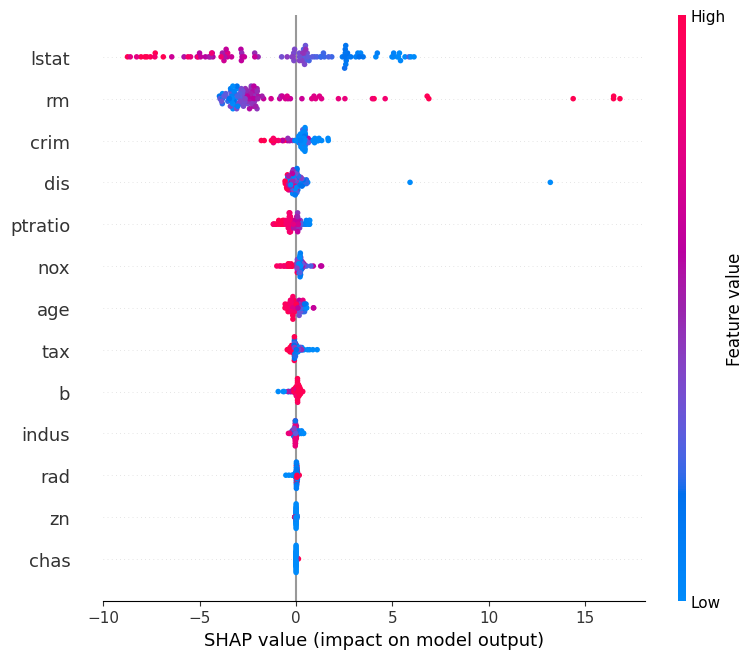

In [3]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="dot")

### 3.2 Gráfico de Barras de Importancia Global

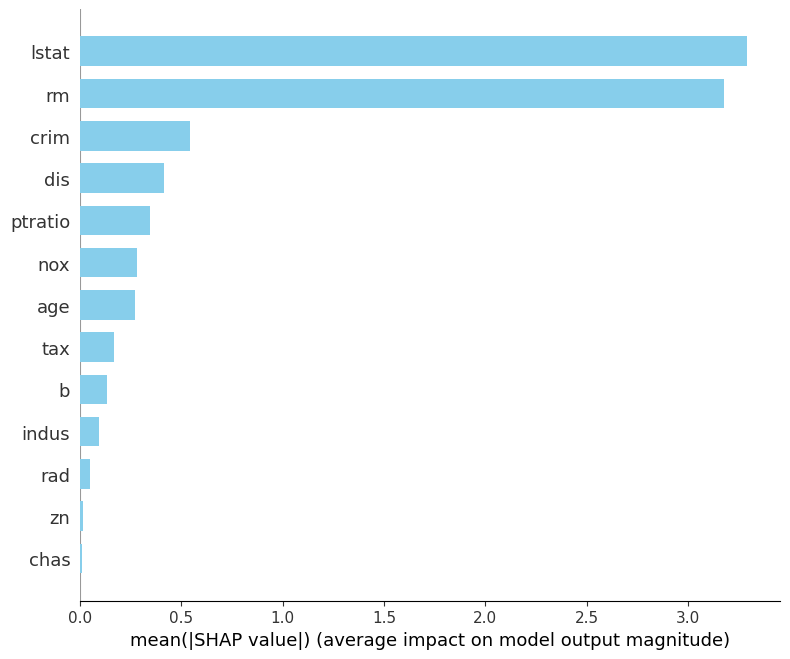

In [4]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", color="skyblue")

## 4. Explicación Local (Una predicción específica)

Elegimos la primera observación del conjunto de prueba.

In [5]:
sample_idx = 0
sample_data = X_test.iloc[sample_idx, :]

print(f"Predicción del modelo: {model.predict([sample_data])[0]:.2f}")
print(f"Valor real: {y_test.iloc[sample_idx, 0]:.2f}")

Predicción del modelo: 22.84
Valor real: 23.60


d:\Programs\Anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


### 4.1 Waterfall Plot

Explica cómo se llega del valor base (promedio de predicciones) al valor predicho final.

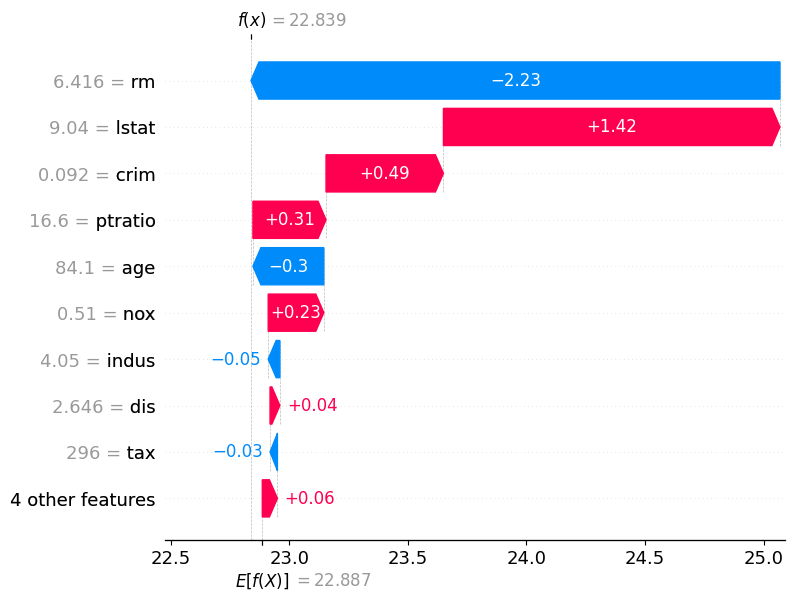

In [6]:
# Para el waterfall plot necesitamos el objeto Explanation
explanation = explainer(X_test)
shap.plots.waterfall(explanation[sample_idx])

### 4.2 Force Plot

Muestra las fuerzas que "empujan" la predicción hacia arriba o hacia abajo.

**Nota sobre errores de Javascript:** Si ves el mensaje "Visualization omitted, Javascript library not loaded", asegúrate de:
1. Haber ejecutado `shap.initjs()` al inicio.
2. Marcar el cuaderno como "Trusted" (File -> Trust Notebook).
3. Si usas JupyterLab o VS Code, puedes usar el parámetro `matplotlib=True` como alternativa estática.

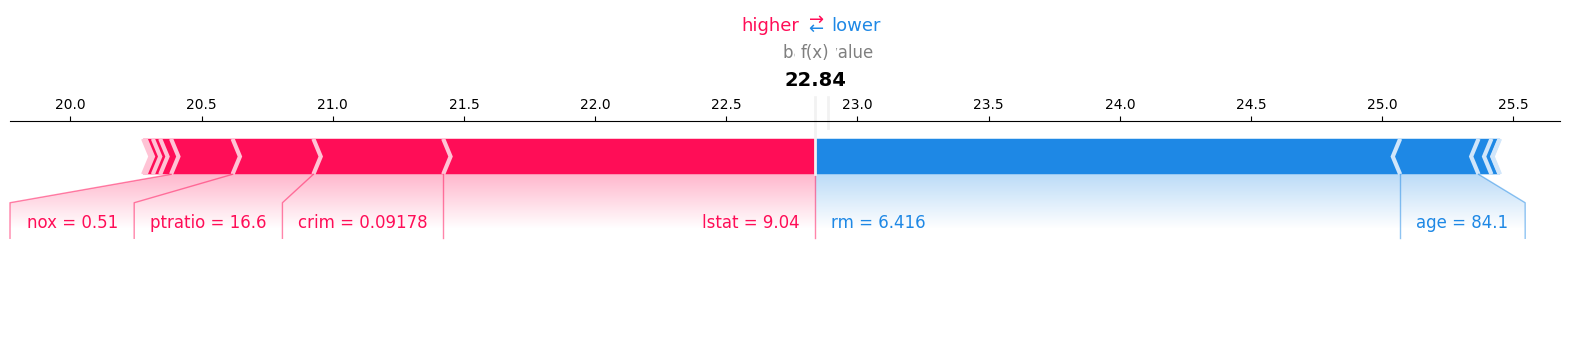

In [11]:
# Opción 1: Interactiva (Requiere Javascript funcional)
# shap.plots.force(explanation[sample_idx])

# Opción 2: Estática (Fallback si Javascript falla)
shap.plots.force(explanation[sample_idx], matplotlib=True)

## 5. Gráficos de Dependencia

Analizan cómo cambia la predicción según el valor de una característica específica, mostrando posibles interacciones.

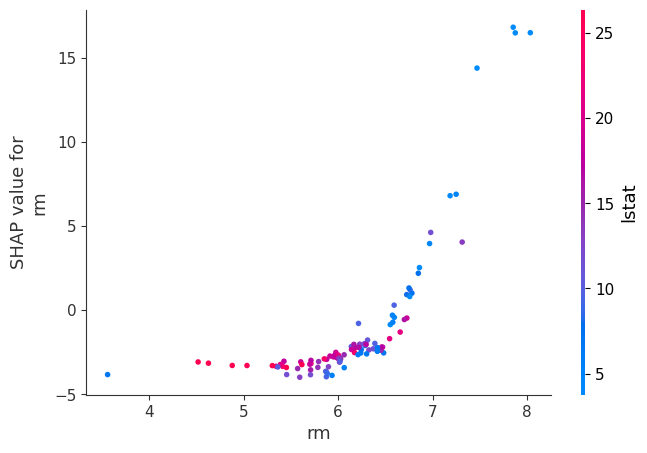

In [12]:
shap.dependence_plot("rm", shap_values, X_test)

## 6. Conclusión SHAP

- `rm` (habitaciones) tiene un impacto positivo fuerte: a más habitaciones, mayor precio.
- `lstat` (bajo estatus) tiene un impacto negativo fuerte: a mayor porcentaje, menor precio.
- SHAP nos permite ver no solo qué variables importan, sino *cómo* y en qué *dirección* afectan la predicción.